In [1]:
using PauliStrings
using PauliStrings.Circuits
using Random, Plots

[ Info: Precompiling IJuliaExt [64482eec-cc57-5312-bea1-9f24eb636db7]
[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]


## Circuit

$L$ layers. Per layer: each qubit gets one of $\{I, H, T\}$ uniformly; each nearest-neighbour pair gets $I$ or $CZ$ with equal probability.

In [2]:
N    = 4
L    = 100
seed = 42

function random_layers(N, L, rng)
    layers = Vector{Vector{Tuple{Symbol,Int,Int}}}()
    for _ in 1:L
        layer = Tuple{Symbol,Int,Int}[]
        for q in 1:N
            r = rand(rng, 1:3)
            r == 2 && push!(layer, (:H, q, 0))
            r == 3 && push!(layer, (:T, q, 0))
        end
        for q in 1:N-1
            rand(rng, Bool) && push!(layer, (:CZ, q, q+1))
        end
        push!(layers, layer)
    end
    return layers
end

layers = random_layers(N, L, MersenneTwister(seed));

## Observable

In [3]:
qubit = 4
O = Operator(N)
O += "Z", qubit

(1.0 + 0.0im) 111Z


## Algorithm 1

Heisenberg picture, gate by gate, dropping any term whose amplitude falls below $\varepsilon$ after each gate. Local $Z$-dephasing at rate $\gamma$ is applied at the end of every layer ($B_k \to e^{-2\gamma q_k} B_k$, $q_k$ = number of $X$ or $Y$). The expectation value on $|0\rangle^{\otimes N}$ is the sum of coefficients on diagonal Pauli strings.

In [6]:
ε = 0.005
γ = 0.01

gate_op(g, q1, q2) = g == :H  ? HGate(N, q1) :
                     g == :T  ? TGate(N, q1) :
                     g == :CZ ? CZGate(N, q1, q2) :
                                error("unknown gate")

function dephase(O, γ)
    γ == 0 && return O
    coefs, strs = op_to_strings(O)
    Onew = Operator(qubitlength(O))
    for i in eachindex(strs)
        q = count(c -> c == 'X' || c == 'Y', strs[i])
        Onew += coefs[i] * exp(-2γ*q), strs[i]
    end
    Onew
end

function expectation_zero(O)
    coefs, strs = op_to_strings(O)
    s = 0.0
    for i in eachindex(strs)
        all(c -> c == '1' || c == 'Z', strs[i]) && (s += real(coefs[i]))
    end
    s
end

z = let O = O
    history = Float64[expectation_zero(O)]
    for layer in layers
        for (g, q1, q2) in layer
            U = gate_op(g, q1, q2)
            O = cutoff(dagger(U) * O * U, ε)
        end
        O = cutoff(dephase(O, γ), ε)
        push!(history, expectation_zero(O))
    end
    history
end

z

101-element Vector{Float64}:
  1.0
  0.9999999999999998
  0.9999999999999996
  0.9999999999999996
  0.9999999999999994
  0.9999999999999989
  0.0
  0.0
  0.960789439152321
  0.9607894391523206
  0.9607894391523203
  0.9607894391523201
  0.0
  ⋮
 -0.002199515992390864
  0.005978728802688668
  0.0059787288026886655
  0.0
  0.0
  0.0
  0.0
  0.00735269059442967
  0.002207273545571118
  0.002207273545571118
  0.002207273545571118
 -0.005145417048858549

## Plot

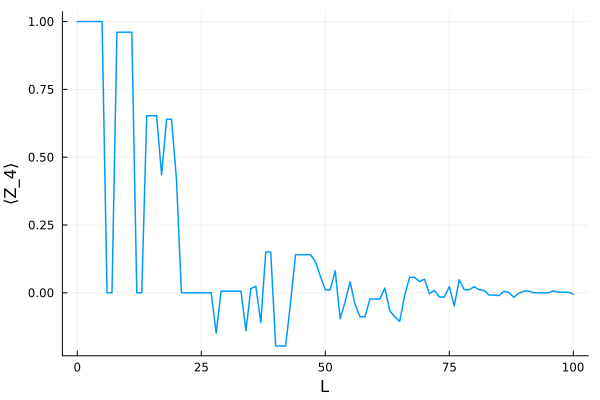

In [7]:
plot(0:L, z; xlabel="L", ylabel="⟨Z_$(qubit)⟩", lw=1.5, legend=false)